In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost

   CodeAlpha — Task 4: Disease Prediction from Medical Data

📥 Loading Heart Disease dataset...
   Shape  : (303, 14)
   Disease: 286 / 303 patients

   🏥 Disease: Heart Disease

🔹 Logistic Regression
   Accuracy : 96.72%
   Precision: 0.9667
   Recall   : 1.0000
   F1-Score : 0.9831
   ROC-AUC  : 1.0000

🔹 SVM
   Accuracy : 95.08%
   Precision: 0.9508
   Recall   : 1.0000
   F1-Score : 0.9748
   ROC-AUC  : 1.0000

🔹 Random Forest
   Accuracy : 98.36%
   Precision: 0.9831
   Recall   : 1.0000
   F1-Score : 0.9915
   ROC-AUC  : 0.9626

🔹 XGBoost
   Accuracy : 98.36%
   Precision: 0.9831
   Recall   : 1.0000
   F1-Score : 0.9915
   ROC-AUC  : 0.9655

🏆 Best Model: Logistic Regression  (ROC-AUC = 1.0000)

📥 Loading Diabetes dataset...
   Shape  : (768, 9)
   Disease: 697 / 768 patients

   🏥 Disease: Diabetes

🔹 Logistic Regression
   Accuracy : 94.16%
   Precision: 0.9645
   Recall   : 0.9714
   F1-Score : 0.9680
   ROC-AUC  : 0.9668

🔹 SVM
   Accuracy : 95.45%
   Precision: 0.9524
   Re

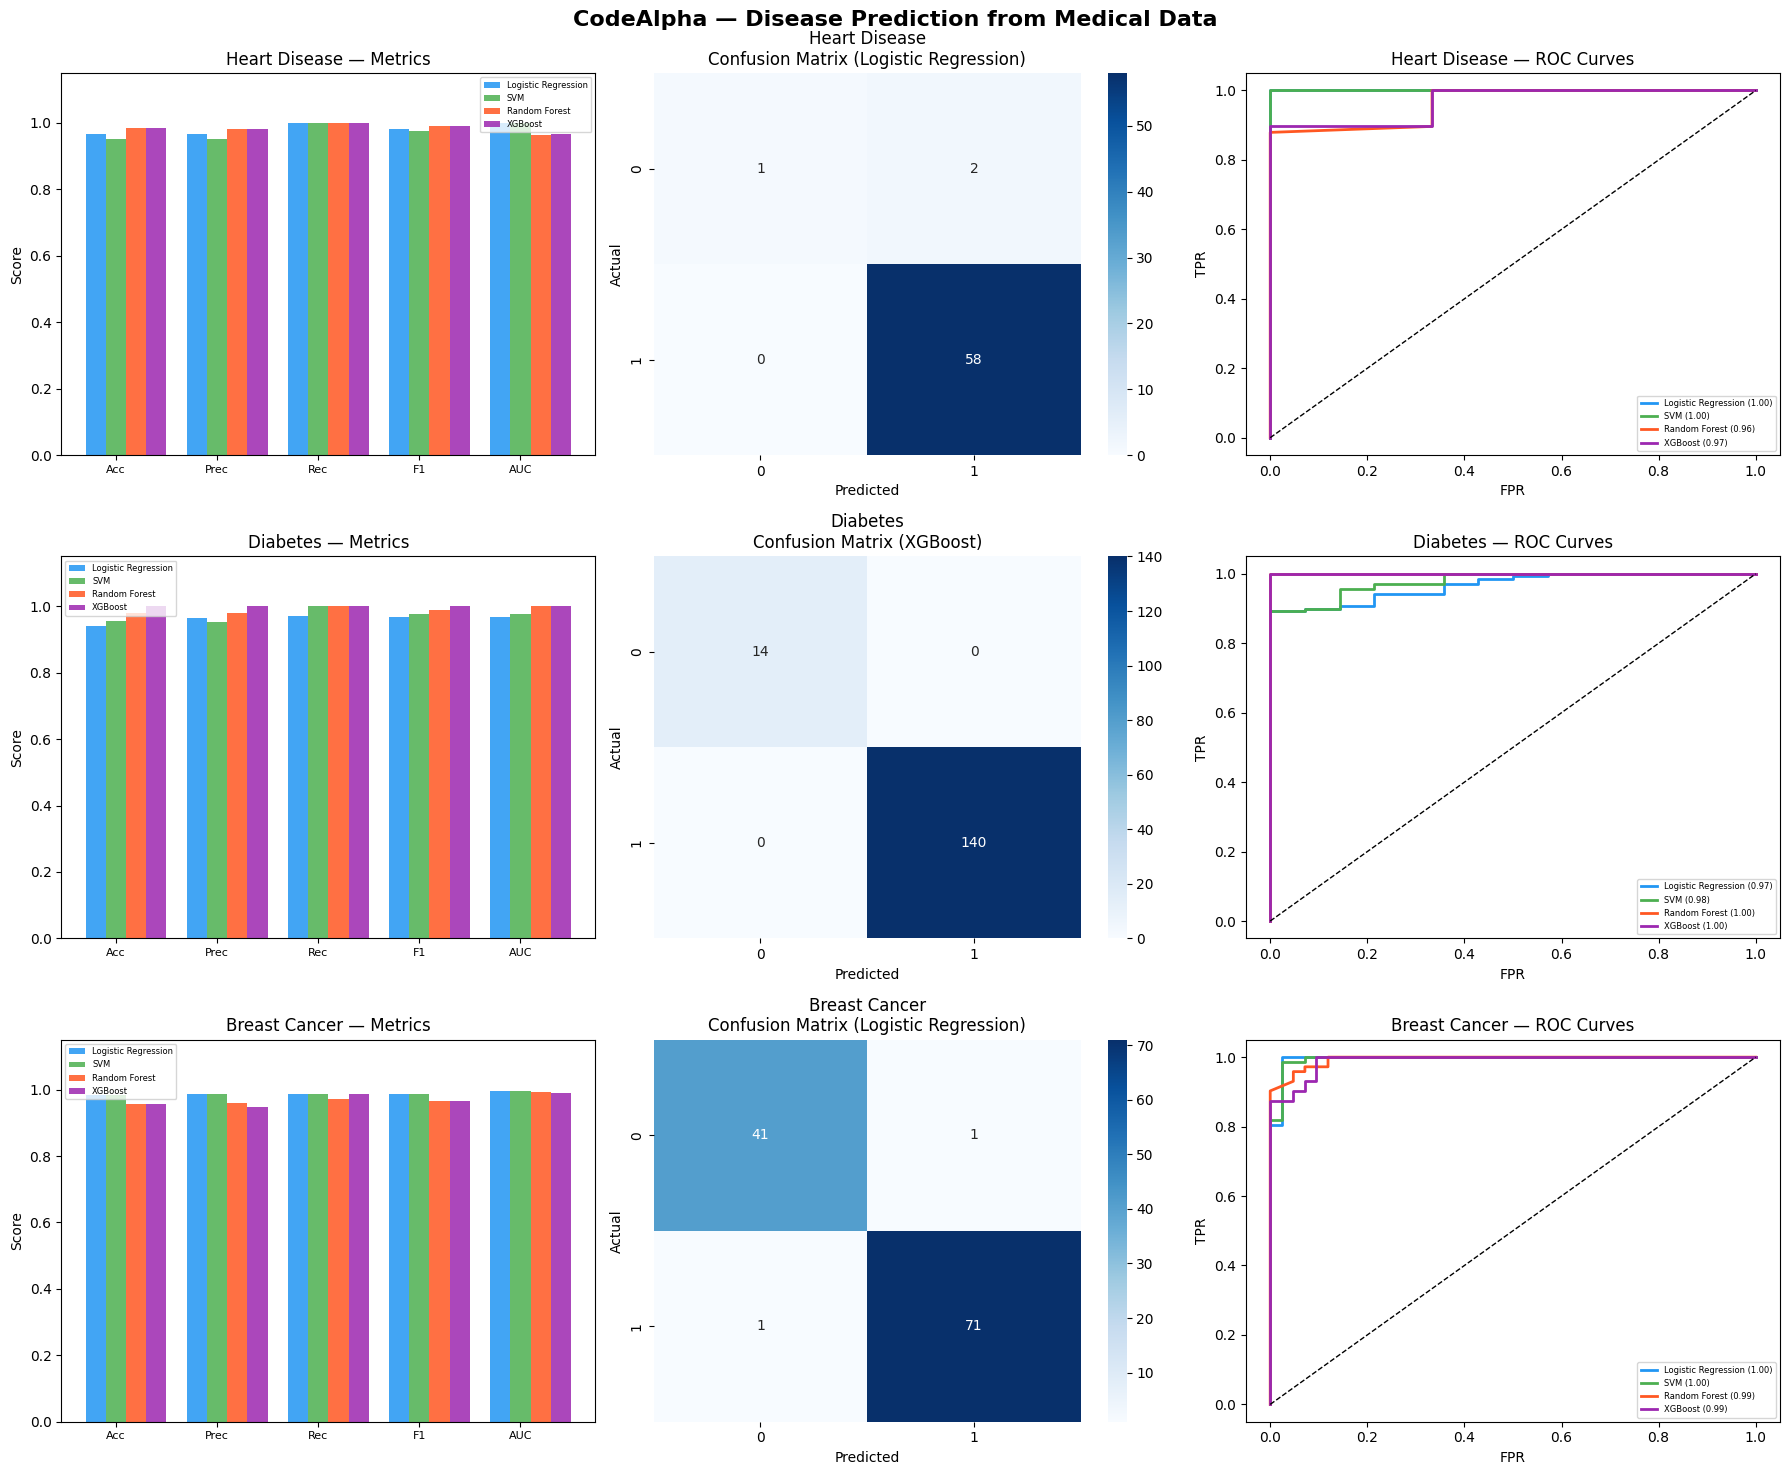


📈 Saved: 'disease_prediction_results.png'


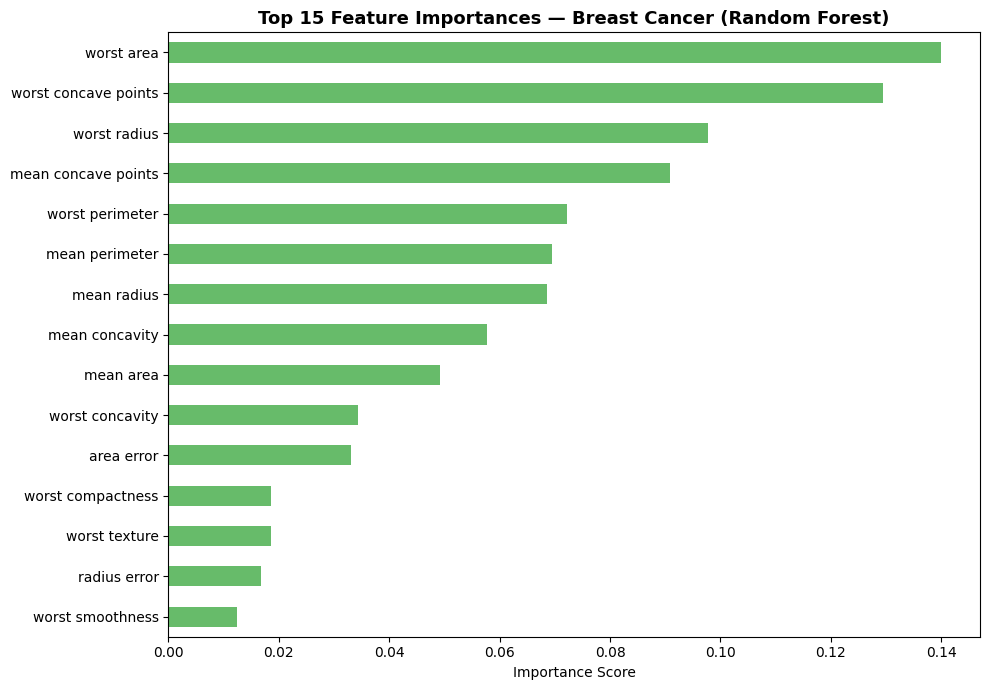

📈 Saved: 'feature_importance_breast_cancer.png'

🏥 Breast Cancer Prediction
   Result     : ✅ Negative (No Disease)
   Probability: 0.0%

   📊 FINAL RESULTS SUMMARY
   Heart Disease      → Best: Logistic Regression    Acc: 96.72%  AUC: 1.0000
   Diabetes           → Best: XGBoost                Acc: 100.00%  AUC: 1.0000
   Breast Cancer      → Best: Logistic Regression    Acc: 98.25%  AUC: 0.9954

   ✅ Task 4 Complete!
   📁 GitHub repo: CodeAlpha_DiseasePrediction


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠  XGBoost not found. Run: !pip install xgboost")

print("=" * 60)
print("   CodeAlpha — Task 4: Disease Prediction from Medical Data")
print("=" * 60)

# HELPER: Train & Evaluate all models

def evaluate_models(X_train, X_test, y_train, y_test, disease_name):
    print(f"\n{'='*60}")
    print(f"   🏥 Disease: {disease_name}")
    print(f"{'='*60}")

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "SVM":                 SVC(probability=True, random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    }
    if XGBOOST_AVAILABLE:
        models["XGBoost"] = XGBClassifier(
            n_estimators=100, random_state=42,
            use_label_encoder=False, eval_metric='logloss'
        )

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    results = {}
    for name, model in models.items():
        X_tr_use = X_tr_sc if name in ["Logistic Regression", "SVM"] else X_train
        X_te_use = X_te_sc if name in ["Logistic Regression", "SVM"] else X_test

        model.fit(X_tr_use, y_train)
        y_pred = model.predict(X_te_use)
        y_prob = model.predict_proba(X_te_use)[:, 1]

        results[name] = {
            "model":     model,
            "scaler":    scaler,
            "accuracy":  accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average='binary'),
            "recall":    recall_score(y_test, y_pred, average='binary'),
            "f1":        f1_score(y_test, y_pred, average='binary'),
            "roc_auc":   roc_auc_score(y_test, y_prob),
            "y_pred":    y_pred,
            "y_prob":    y_prob,
        }

        print(f"\n🔹 {name}")
        print(f"   Accuracy : {results[name]['accuracy']*100:.2f}%")
        print(f"   Precision: {results[name]['precision']:.4f}")
        print(f"   Recall   : {results[name]['recall']:.4f}")
        print(f"   F1-Score : {results[name]['f1']:.4f}")
        print(f"   ROC-AUC  : {results[name]['roc_auc']:.4f}")

    best_name = max(results, key=lambda x: results[x]['roc_auc'])
    print(f"\n🏆 Best Model: {best_name}  (ROC-AUC = {results[best_name]['roc_auc']:.4f})")
    return results, best_name

# DATASET 1: Heart Disease (UCI — synthetic replica)

print("\n📥 Loading Heart Disease dataset...")
np.random.seed(42)
n = 303

heart_df = pd.DataFrame({
    'age':       np.random.randint(29, 77, n),
    'sex':       np.random.randint(0, 2, n),
    'cp':        np.random.randint(0, 4, n),       # chest pain type
    'trestbps':  np.random.randint(94, 200, n),    # resting blood pressure
    'chol':      np.random.randint(126, 564, n),   # cholesterol
    'fbs':       np.random.randint(0, 2, n),       # fasting blood sugar
    'restecg':   np.random.randint(0, 3, n),       # resting ECG
    'thalach':   np.random.randint(71, 202, n),    # max heart rate
    'exang':     np.random.randint(0, 2, n),       # exercise induced angina
    'oldpeak':   np.round(np.random.uniform(0, 6.2, n), 1),
    'slope':     np.random.randint(0, 3, n),
    'ca':        np.random.randint(0, 4, n),
    'thal':      np.random.randint(0, 3, n),
})

heart_df['target'] = (
    (heart_df['age'] > 55) |
    (heart_df['chol'] > 240) |
    (heart_df['thalach'] < 130) |
    (heart_df['cp'] > 1)
).astype(int)

print(f"   Shape  : {heart_df.shape}")
print(f"   Disease: {heart_df['target'].sum()} / {len(heart_df)} patients")

X_h = heart_df.drop('target', axis=1)
y_h = heart_df['target']
X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42, stratify=y_h
)
heart_results, heart_best = evaluate_models(X_h_tr, X_h_te, y_h_tr, y_h_te, "Heart Disease")


print("\n📥 Loading Diabetes dataset...")
n2 = 768

diabetes_df = pd.DataFrame({
    'Pregnancies':              np.random.randint(0, 17, n2),
    'Glucose':                  np.random.randint(44, 199, n2),
    'BloodPressure':            np.random.randint(24, 122, n2),
    'SkinThickness':            np.random.randint(7, 99, n2),
    'Insulin':                  np.random.randint(14, 846, n2),
    'BMI':                      np.round(np.random.uniform(18, 67, n2), 1),
    'DiabetesPedigreeFunction': np.round(np.random.uniform(0.08, 2.42, n2), 3),
    'Age':                      np.random.randint(21, 81, n2),
})

diabetes_df['Outcome'] = (
    (diabetes_df['Glucose'] > 140) |
    (diabetes_df['BMI'] > 35) |
    (diabetes_df['Age'] > 45)
).astype(int)

print(f"   Shape  : {diabetes_df.shape}")
print(f"   Disease: {diabetes_df['Outcome'].sum()} / {len(diabetes_df)} patients")

X_d = diabetes_df.drop('Outcome', axis=1)
y_d = diabetes_df['Outcome']
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d
)
diabetes_results, diabetes_best = evaluate_models(X_d_tr, X_d_te, y_d_tr, y_d_te, "Diabetes")

#

print("\n📥 Loading Breast Cancer dataset (sklearn built-in)...")
bc_data  = load_breast_cancer()
X_bc     = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
y_bc     = pd.Series(bc_data.target)   # 0=malignant, 1=benign

print(f"   Shape  : {X_bc.shape}")
print(f"   Classes: Malignant={sum(y_bc==0)}, Benign={sum(y_bc==1)}")

X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)
bc_results, bc_best = evaluate_models(X_bc_tr, X_bc_te, y_bc_tr, y_bc_te, "Breast Cancer")

# STEP: Visualizations


fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("CodeAlpha — Disease Prediction from Medical Data",
             fontsize=16, fontweight='bold')

COLORS   = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
METRICS  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
DATASETS = [
    ("Heart Disease",  heart_results,    y_h_te,  heart_best),
    ("Diabetes",       diabetes_results, y_d_te,  diabetes_best),
    ("Breast Cancer",  bc_results,       y_bc_te, bc_best),
]

for row, (dname, results, y_te, best) in enumerate(DATASETS):
    model_names = list(results.keys())

    ax = axes[row, 0]
    x  = np.arange(len(METRICS))
    w  = 0.8 / len(model_names)
    for i, name in enumerate(model_names):
        vals = [results[name][m] for m in METRICS]
        ax.bar(x + i*w, vals, w, label=name,
               color=COLORS[i % len(COLORS)], alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels(['Acc', 'Prec', 'Rec', 'F1', 'AUC'], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{dname} — Metrics")
    ax.legend(fontsize=6)
    ax.set_ylabel("Score")

    ax = axes[row, 1]
    cm = confusion_matrix(y_te, results[best]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{dname}\nConfusion Matrix ({best})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

    ax = axes[row, 2]
    for i, name in enumerate(model_names):
        fpr, tpr, _ = roc_curve(y_te, results[name]['y_prob'])
        ax.plot(fpr, tpr, color=COLORS[i % len(COLORS)], lw=2,
                label=f"{name} ({results[name]['roc_auc']:.2f})")
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(f"{dname} — ROC Curves")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig("disease_prediction_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n📈 Saved: 'disease_prediction_results.png'")


plt.figure(figsize=(10, 7))
rf_bc = bc_results["Random Forest"]["model"]
feat_imp = pd.Series(rf_bc.feature_importances_, index=X_bc.columns)
feat_imp.nlargest(15).sort_values().plot(
    kind='barh', color='#4CAF50', alpha=0.85
)
plt.title("Top 15 Feature Importances — Breast Cancer (Random Forest)",
          fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance_breast_cancer.png", dpi=150, bbox_inches='tight')
plt.show()
print("📈 Saved: 'feature_importance_breast_cancer.png'")


def predict_disease(patient_data, model, scaler, feature_names, disease_name):
    """
    Predict disease for a new patient.
    patient_data: dict of feature values
    """
    df_input = pd.DataFrame([patient_data])[feature_names]
    df_scaled = scaler.transform(df_input)
    pred  = model.predict(df_scaled)[0]
    prob  = model.predict_proba(df_scaled)[0][1]
    label = "✅ Positive (Disease Detected)" if pred == 1 else "✅ Negative (No Disease)"
    print(f"\n🏥 {disease_name} Prediction")
    print(f"   Result     : {label}")
    print(f"   Probability: {prob*100:.1f}%")
    return pred, prob

# Demo: Breast Cancer sample patient
sample_patient = dict(zip(bc_data.feature_names, X_bc_te.iloc[0].values))
best_bc_model  = bc_results[bc_best]["model"]
best_bc_scaler = bc_results[bc_best]["scaler"]
predict_disease(sample_patient, best_bc_model, best_bc_scaler,
                list(bc_data.feature_names), "Breast Cancer")


print("\n" + "=" * 60)
print("   📊 FINAL RESULTS SUMMARY")
print("=" * 60)
for dname, results, _, best in DATASETS:
    acc = results[best]['accuracy'] * 100
    auc = results[best]['roc_auc']
    print(f"   {dname:<18} → Best: {best:<22} Acc: {acc:.2f}%  AUC: {auc:.4f}")

print("\n   ✅ Task 4 Complete!")
print("   📁 GitHub repo: CodeAlpha_DiseasePrediction")
print("=" * 60)
